# 01B · Home vs Away overview

Análisis del dashboard de equipos enfocado en el split de localía (Regular Season 2024-25).

## 1. Introducción

En este cuaderno exploramos cómo varían las métricas de rendimiento de cada franquicia dependiendo de si juegan en casa (`Home`) o fuera (`Away`). Evaluaremos resultados, eficiencia ofensiva y correlaciones clave para detectar qué factores impulsan el éxito según la localización.

## 2. Carga de datos

Leemos el parquet consolidado de `team_dashboard_by_general_splits`, filtrando la temporada objetivo y seleccionando únicamente el `source_dataset = 1`, que corresponde a los splits Home/Away. Se inspecciona la forma del DataFrame, el listado de columnas disponibles y las primeras filas para validar el filtrado.

In [14]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (12, 6)

NOTEBOOK_DIR = Path().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parents[3]
DATA_DIR = PROJECT_ROOT / "00_data"
FIGURES_DIR = PROJECT_ROOT / "02a_reports" / "figures" / "home_away"
TABLES_DIR = PROJECT_ROOT / "02a_reports" / "tables" / "home_away"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

INTERMEDIATE_PATH = (
    DATA_DIR
    / "00b_intermediate"
    / "team_dashboard"
    / "general_splits"
    / "2024-25"
    / "Regular Season"
    / "team_dashboard__general_splits.parquet"
)
DATASET_REFERENCE_ID = 1
SOURCE_DATASET_ID = 1
SEASON_TARGET = "2024-25"

print(f"Proyecto: {PROJECT_ROOT}")
print(f"Parquet intermedio: {INTERMEDIATE_PATH}")
print(f"Dataset de referencia: {DATASET_REFERENCE_ID}")
print(f"Source dataset (Home/Away): {SOURCE_DATASET_ID}")
print(f"Temporada objetivo: {SEASON_TARGET}")

Proyecto: /Users/pablo/Documents/BigData/BasketballAnalysis
Parquet intermedio: /Users/pablo/Documents/BigData/BasketballAnalysis/00_data/00b_intermediate/team_dashboard/general_splits/2024-25/Regular Season/team_dashboard__general_splits.parquet
Dataset de referencia: 1
Source dataset (Home/Away): 1
Temporada objetivo: 2024-25


In [19]:
general_df = pd.read_parquet(INTERMEDIATE_PATH)

df = general_df.copy()

# --- Filtro dataset (usa 'dataset_1') ---
ds_col = colmap.get("dataset")
if ds_col:
    ds_target = f"dataset_{str(DATASET_REFERENCE_ID)}"
    df = df[df[ds_col].astype(str) == ds_target]
    print(f"Filtrado dataset == '{ds_target}' → filas:", len(df))
else:
    print("⚠️ No se encontró columna 'dataset'.")

# --- Filtro source_dataset (usa '1') ---
sds_col = colmap.get("source_dataset")
if sds_col:
    df = df[df[sds_col].astype(str) == str(SOURCE_DATASET_ID)]
    print(f"Filtrado source_dataset == {SOURCE_DATASET_ID} → filas:", len(df))
else:
    print("⚠️ No se encontró columna 'source_dataset'.")

analysis_df = df.copy()

print("\n---- RESULTADOS ----")
print("general_df shape:", general_df.shape)
print("analysis_df shape:", analysis_df.shape)
print("columnas disponibles:", list(analysis_df.columns))
if sds_col:
    print("source_dataset únicos (post-filtro):", sorted(analysis_df[sds_col].astype(str).unique()))
if season_col:
    print("season únicos (post-filtro):", sorted(analysis_df[season_col].astype(str).unique()))

display(analysis_df.head())

Filtrado dataset == 'dataset_1' → filas: 68
Filtrado source_dataset == 1 → filas: 68

---- RESULTADOS ----
general_df shape: (672, 69)
analysis_df shape: (68, 69)
columnas disponibles: ['GROUP_SET', 'GROUP_VALUE', 'SEASON_YEAR', 'GP', 'W', 'L', 'W_PCT', 'MIN', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB', 'REB', 'AST', 'TOV', 'STL', 'BLK', 'BLKA', 'PF', 'PFD', 'PTS', 'PLUS_MINUS', 'GP_RANK', 'W_RANK', 'L_RANK', 'W_PCT_RANK', 'MIN_RANK', 'FGM_RANK', 'FGA_RANK', 'FG_PCT_RANK', 'FG3M_RANK', 'FG3A_RANK', 'FG3_PCT_RANK', 'FTM_RANK', 'FTA_RANK', 'FT_PCT_RANK', 'OREB_RANK', 'DREB_RANK', 'REB_RANK', 'AST_RANK', 'TOV_RANK', 'STL_RANK', 'BLK_RANK', 'BLKA_RANK', 'PF_RANK', 'PFD_RANK', 'PTS_RANK', 'PLUS_MINUS_RANK', 'season', 'endpoint', 'TEAM_ID', 'season_type', 'dataset', 'TEAM_NAME', 'source_dataset', 'split_type', 'split_value', 'TEAM_GAME_LOCATION', 'GAME_RESULT', 'SEASON_MONTH_NAME', 'SEASON_SEGMENT', 'TEAM_DAYS_REST_RANGE']
source_dataset únicos 

,GROUP_SET,GROUP_VALUE,SEASON_YEAR,GP,W,L,W_PCT,MIN,FGM,FGA,...,dataset,TEAM_NAME,source_dataset,split_type,split_value,TEAM_GAME_LOCATION,GAME_RESULT,SEASON_MONTH_NAME,SEASON_SEGMENT,TEAM_DAYS_REST_RANGE
60,Location,Home,None,43,21,22,0.488,2045.000000,1810,3856,...,dataset_1,Atlanta Hawks,1,team_game_location,Home,Home,None,None,None,None
61,Location,Neutral,None,1,0,1,0.000,48.000000,35,82,...,dataset_1,Atlanta Hawks,1,team_game_location,Neutral,Neutral,None,None,None,None
62,Location,Road,None,43,19,24,0.442,2064.883333,1851,3947,...,dataset_1,Atlanta Hawks,1,team_game_location,Road,Road,None,None,None,None
63,Location,Home,None,44,28,16,0.636,2103.000000,1832,3930,...,dataset_1,Boston Celtics,1,team_game_location,Home,Home,None,None,None,None
64,Location,Road,None,43,35,8,0.814,2063.000000,1753,3831,...,dataset_1,Boston Celtics,1,team_game_location,Road,Road,None,None,None,None


## 3. Resumen general Home vs Away

Agregamos la información por franquicia y localización para resumir victorias, derrotas y porcentaje de victorias (`W_PCT`). También calculamos el total de partidos jugados combinando ambos escenarios.

In [16]:
analysis_std = analysis_df.rename(columns={col: col.upper() for col in analysis_df.columns})
COLUMN_LOOKUP = {col: col for col in analysis_std.columns}

def require_columns(labels):
    missing = [label for label in labels if label not in COLUMN_LOOKUP]
    if missing:
        raise KeyError(f"Columnas faltantes en el parquet filtrado: {missing}")
    return [COLUMN_LOOKUP[label] for label in labels]

TEAM_KEYS = require_columns(["TEAM_ID", "TEAM_NAME"])
location_col = require_columns(["GROUP_VALUE"])[0]

summary_needed = ["GP", "W", "L", "W_PCT"]
available_summary = [c for c in summary_needed if c in COLUMN_LOOKUP]

if not {"W", "L"}.issubset(set(available_summary)):
    print("⚠️ No hay columnas suficientes de victorias/derrotas para construir el resumen Home/Away.")
    summary_table = analysis_std[TEAM_KEYS].drop_duplicates().reset_index(drop=True)
else:
    summary_cols = require_columns(available_summary)

    summary_df = analysis_std[TEAM_KEYS + [location_col] + summary_cols].copy()

    def normalize_location(value):
        text = str(value).strip().lower()
        if "home" in text:
            return "HOME"
        if "away" in text or "road" in text:
            return "AWAY"
        return text.upper() if text else "UNKNOWN"

    summary_df["LOCATION"] = summary_df[location_col].map(normalize_location)

    agg_funcs = {col: "sum" for col in summary_cols}
    location_summary = (
        summary_df.groupby(TEAM_KEYS + ["LOCATION"], dropna=False)
        .agg(agg_funcs)
        .reset_index()
    )

    from functools import reduce
    pivot_frames = []
    for metric in available_summary:
        pivot = (
            location_summary
            .pivot_table(index=TEAM_KEYS, columns="LOCATION", values=metric, aggfunc="sum")
            .rename(columns=lambda loc: f"{metric}_{loc}")
        )
        pivot_frames.append(pivot)

    summary_wide = reduce(lambda left, right: left.join(right, how="outer"), pivot_frames)
    summary_wide = summary_wide.reset_index()

    if {f"GP_{loc}" for loc in ["HOME", "AWAY"]}.issubset(summary_wide.columns):
        summary_wide["TOTAL_GP"] = summary_wide.get("GP_HOME", 0).fillna(0) + summary_wide.get("GP_AWAY", 0).fillna(0)
    else:
        summary_wide["TOTAL_GP"] = summary_wide.filter(like="GP_").sum(axis=1)

    ordered_cols = TEAM_KEYS + [
        "W_HOME", "L_HOME", "W_PCT_HOME",
        "W_AWAY", "L_AWAY", "W_PCT_AWAY",
        "TOTAL_GP",
    ]
    existing_cols = [col for col in ordered_cols if col in summary_wide.columns]
    summary_table = summary_wide[existing_cols + [col for col in summary_wide.columns if col not in existing_cols]]

if not summary_table.empty:
    display(summary_table.head())

summary_path = TABLES_DIR / "resumen_home_away.csv"
summary_table.to_csv(summary_path, index=False)
print("Resumen exportado a", summary_path)

LOCATION,TEAM_ID,TEAM_NAME,W_HOME,L_HOME,W_PCT_HOME,W_AWAY,L_AWAY,W_PCT_AWAY,TOTAL_GP,GP_AWAY,GP_HOME,GP_NEUTRAL,W_NEUTRAL,L_NEUTRAL,W_PCT_NEUTRAL
0,1610612737,Atlanta Hawks,21.0,22.0,0.488,19.0,24.0,0.442,86.0,43.0,43.0,1.0,0.0,1.0,0.0
1,1610612738,Boston Celtics,28.0,16.0,0.636,35.0,8.0,0.814,87.0,43.0,44.0,NaN,NaN,NaN,NaN
2,1610612739,Cleveland Cavaliers,35.0,9.0,0.795,31.0,12.0,0.721,87.0,43.0,44.0,NaN,NaN,NaN,NaN
3,1610612740,New Orleans Pelicans,14.0,29.0,0.326,7.0,37.0,0.159,87.0,44.0,43.0,NaN,NaN,NaN,NaN
4,1610612741,Chicago Bulls,20.0,23.0,0.465,21.0,23.0,0.477,87.0,44.0,43.0,NaN,NaN,NaN,NaN


Resumen exportado a /Users/pablo/Documents/BigData/BasketballAnalysis/02a_reports/tables/home_away/resumen_home_away.csv


## 4. Métricas ofensivas Home vs Away

Comparamos porcentajes de tiro, puntos y diferencial (`PLUS_MINUS`) para cada franquicia según juegue en casa o fuera. Se generan gráficos de barras agrupadas y se exportan las figuras.

Tabla ofensiva exportada a /Users/pablo/Documents/BigData/BasketballAnalysis/02a_reports/tables/home_away/ofensiva_home_away.csv


LOCATION,TEAM_ID,TEAM_NAME,FG_PCT_AWAY,FG_PCT_HOME,FG_PCT_NEUTRAL,FG3_PCT_AWAY,FG3_PCT_HOME,FG3_PCT_NEUTRAL,FT_PCT_AWAY,FT_PCT_HOME,FT_PCT_NEUTRAL,PTS_AWAY,PTS_HOME,PTS_NEUTRAL,PLUS_MINUS_AWAY,PLUS_MINUS_HOME,PLUS_MINUS_NEUTRAL
0,1610612737,Atlanta Hawks,0.469,0.469,0.427,0.362,0.351,0.417,0.765,0.777,0.647,5047.0,4973.0,102.0,-46.0,-61.0,-8.0
1,1610612738,Boston Celtics,0.458,0.466,NaN,0.363,0.369,NaN,0.792,0.798,NaN,4917.0,5096.0,NaN,405.0,340.0,NaN
2,1610612739,Cleveland Cavaliers,0.487,0.491,NaN,0.378,0.379,NaN,0.790,0.763,NaN,5161.0,5303.0,NaN,313.0,465.0,NaN
3,1610612740,New Orleans Pelicans,0.453,0.449,NaN,0.339,0.352,NaN,0.731,0.780,NaN,4695.0,4715.0,NaN,-574.0,-236.0,NaN
4,1610612741,Chicago Bulls,0.471,0.462,NaN,0.370,0.360,NaN,0.802,0.809,NaN,5121.0,4978.0,NaN,-78.0,-83.0,NaN


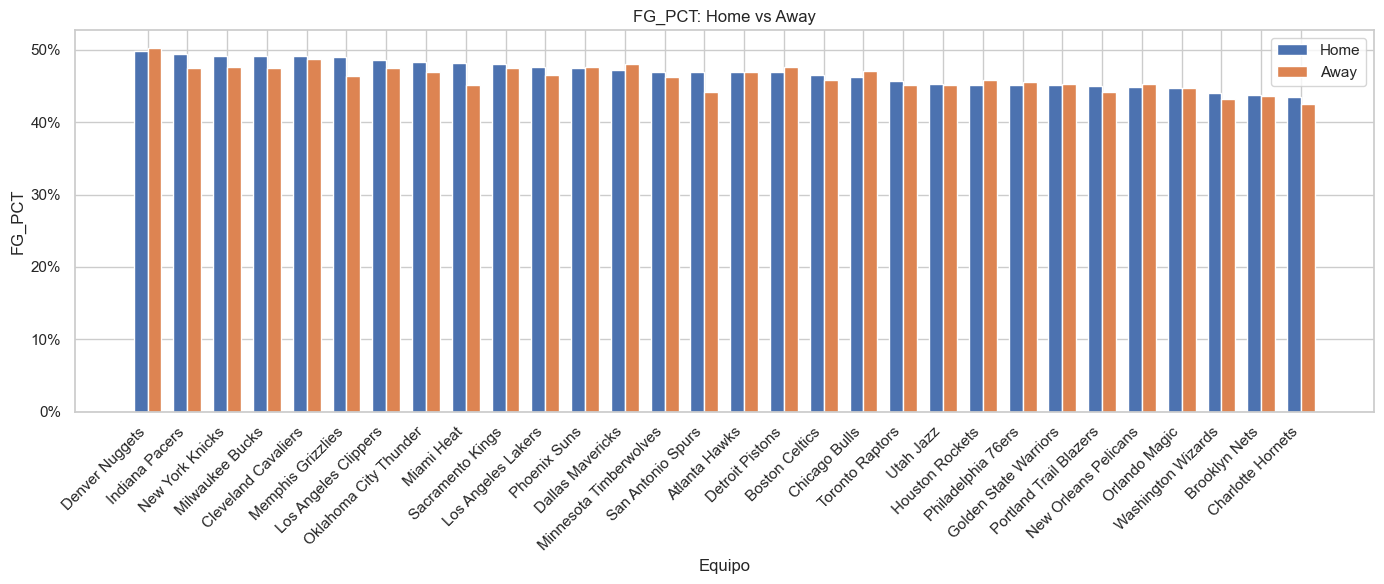

Figura guardada en /Users/pablo/Documents/BigData/BasketballAnalysis/02a_reports/figures/home_away/fg_pct_home_vs_away.png


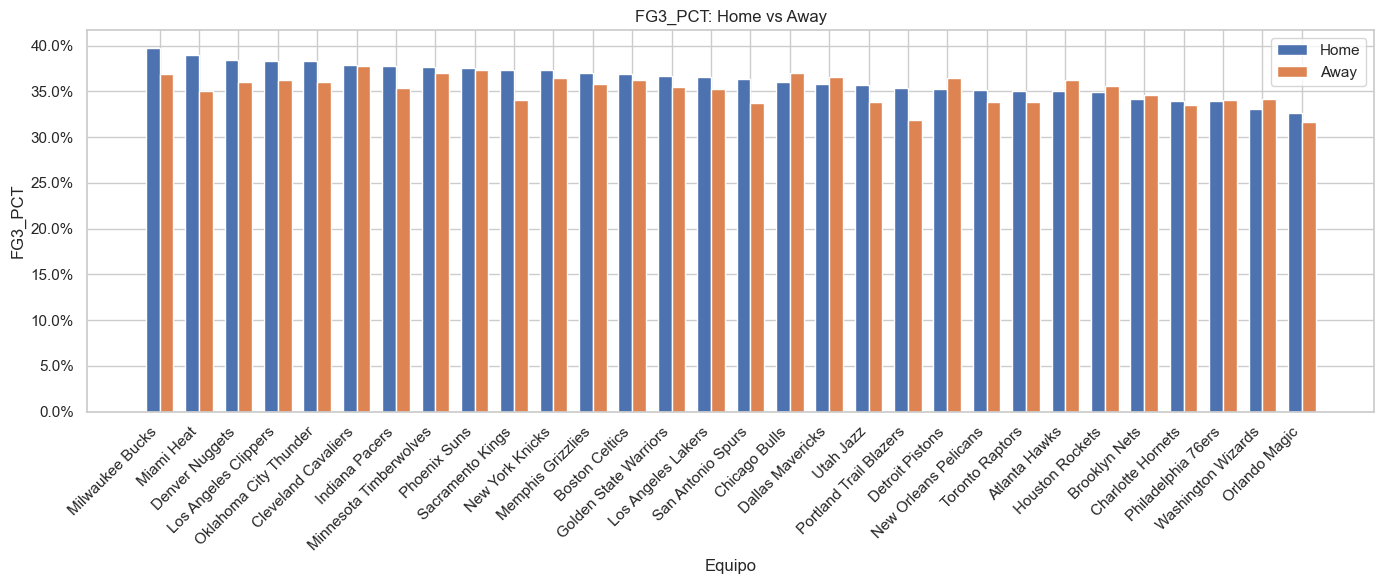

Figura guardada en /Users/pablo/Documents/BigData/BasketballAnalysis/02a_reports/figures/home_away/fg3_pct_home_vs_away.png


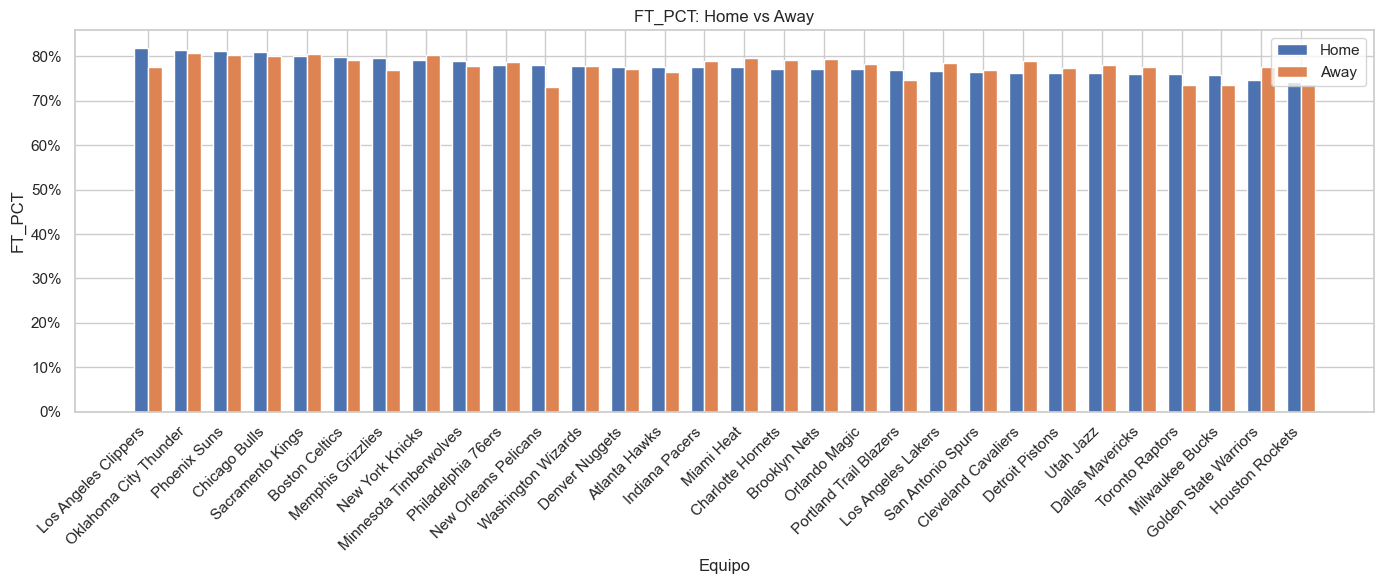

Figura guardada en /Users/pablo/Documents/BigData/BasketballAnalysis/02a_reports/figures/home_away/ft_pct_home_vs_away.png


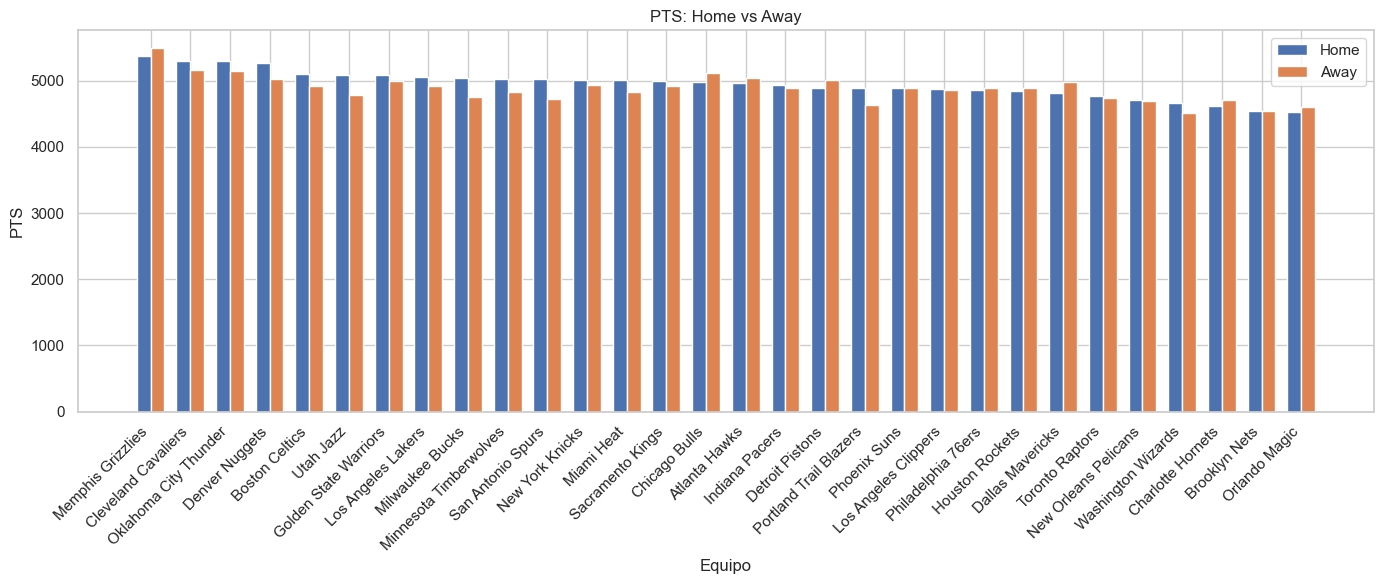

Figura guardada en /Users/pablo/Documents/BigData/BasketballAnalysis/02a_reports/figures/home_away/pts_home_vs_away.png


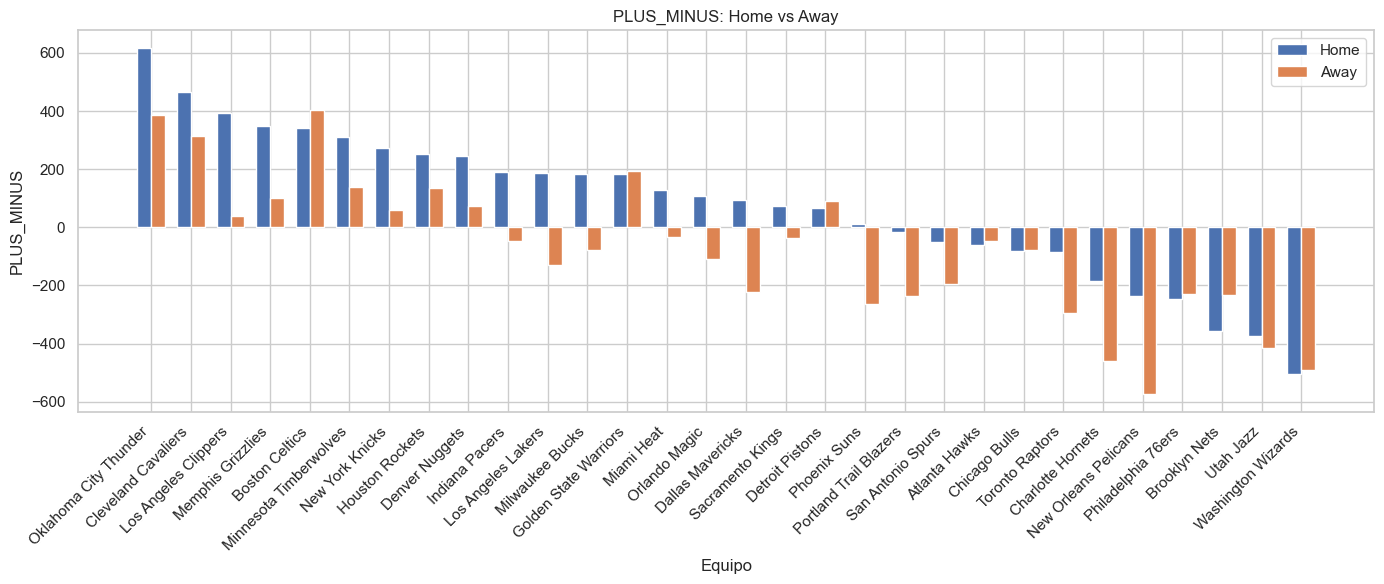

Figura guardada en /Users/pablo/Documents/BigData/BasketballAnalysis/02a_reports/figures/home_away/plus_minus_home_vs_away.png


In [17]:
offensive_metrics = ["FG_PCT", "FG3_PCT", "FT_PCT", "PTS", "PLUS_MINUS"]
available_offensive = [metric for metric in offensive_metrics if metric in COLUMN_LOOKUP]

if not available_offensive:
    print("⚠️ No hay métricas ofensivas disponibles para el análisis Home/Away.")
    offensive_table = analysis_std[TEAM_KEYS].drop_duplicates().reset_index(drop=True)
else:
    off_cols = require_columns(available_offensive)

    off_df = analysis_std[TEAM_KEYS + [location_col] + off_cols].copy()
    off_df["LOCATION"] = off_df[location_col].map(normalize_location)

    agg_off = (
        off_df.groupby(TEAM_KEYS + ["LOCATION"], dropna=False)
        .agg({col: "mean" for col in off_cols})
        .reset_index()
    )

    from functools import reduce
    wide_metrics = []
    for metric in available_offensive:
        pivot = (
            agg_off.pivot_table(index=TEAM_KEYS, columns="LOCATION", values=metric, aggfunc="mean")
            .rename(columns=lambda loc: f"{metric}_{loc}")
        )
        wide_metrics.append(pivot)

    offensive_table = reduce(lambda left, right: left.join(right, how="outer"), wide_metrics).reset_index()

    table_off_path = TABLES_DIR / "ofensiva_home_away.csv"
    offensive_table.to_csv(table_off_path, index=False)
    print("Tabla ofensiva exportada a", table_off_path)

    display(offensive_table.head())

    for metric in available_offensive:
        metric_cols = [f"{metric}_{loc}" for loc in ["HOME", "AWAY"] if f"{metric}_{loc}" in offensive_table.columns]
        if len(metric_cols) < 2:
            print(f"⚠️ Métrica '{metric}' no tiene ambos splits. Se omite el gráfico.")
            continue

        plot_df = offensive_table[[COLUMN_LOOKUP["TEAM_NAME"]] + metric_cols].copy()
        plot_df = plot_df.sort_values(metric_cols[0], ascending=False)

        fig, ax = plt.subplots(figsize=(14, 6))
        width = 0.35
        x = range(len(plot_df))
        ax.bar([i - width / 2 for i in x], plot_df[metric_cols[0]], width=width, label=metric_cols[0].split('_')[-1].title())
        ax.bar([i + width / 2 for i in x], plot_df[metric_cols[1]], width=width, label=metric_cols[1].split('_')[-1].title())
        ax.set_xticks(list(x))
        ax.set_xticklabels(plot_df[COLUMN_LOOKUP["TEAM_NAME"]], rotation=45, ha="right")
        ax.set_title(f"{metric}: Home vs Away")
        ax.set_xlabel("Equipo")
        ax.set_ylabel(metric)
        if metric.endswith("_PCT"):
            ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
        ax.legend()
        plt.tight_layout()

        figure_path = FIGURES_DIR / f"{metric.lower()}_home_vs_away.png"
        fig.savefig(figure_path, dpi=150)
        plt.show()
        print("Figura guardada en", figure_path)

## 5. Correlaciones

Creamos una matriz de correlación que considera las métricas ofensivas clave duplicadas por localización. Esto permite detectar patrones que se repiten en casa y fuera.

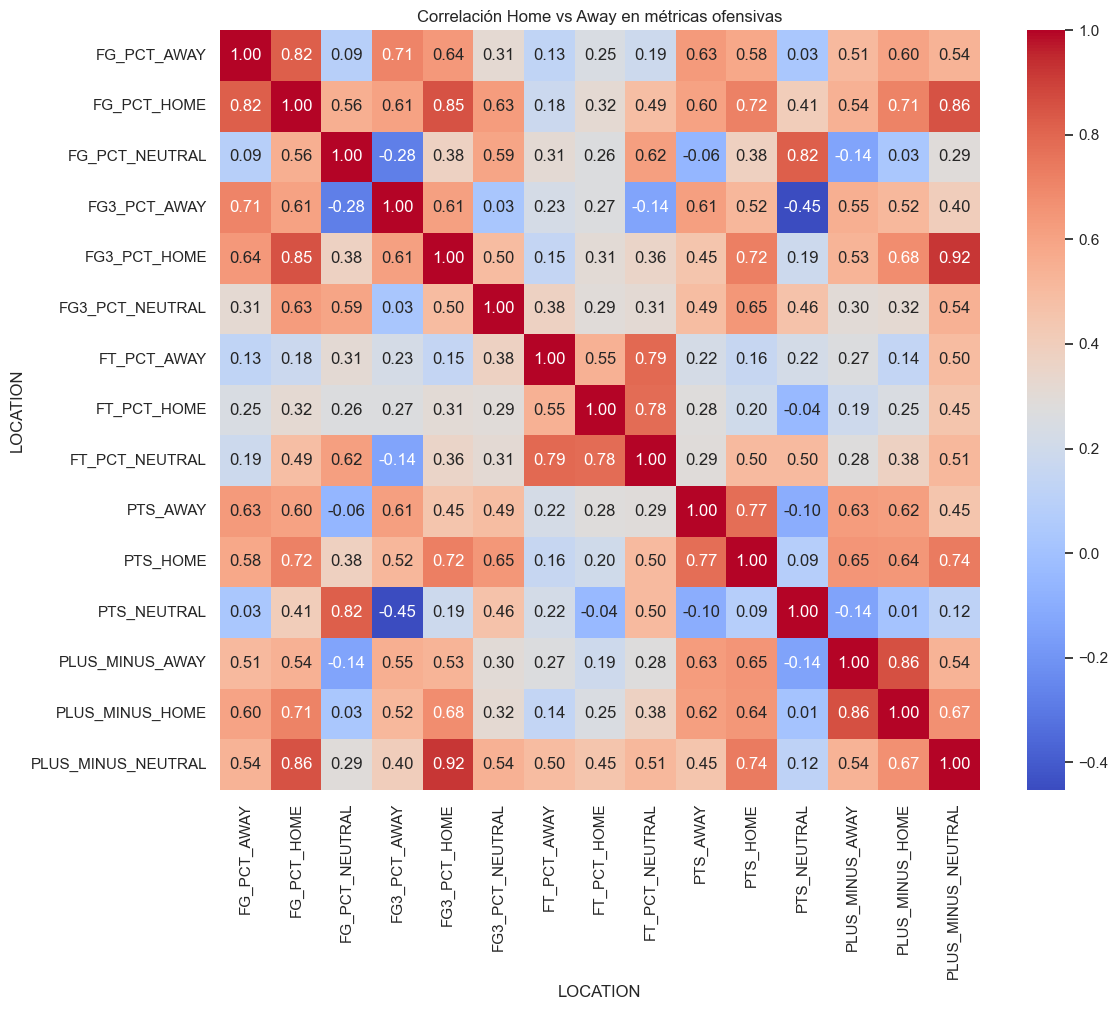

Figura guardada en /Users/pablo/Documents/BigData/BasketballAnalysis/02a_reports/figures/home_away/correlacion_home_away.png
Matriz de correlación exportada a /Users/pablo/Documents/BigData/BasketballAnalysis/02a_reports/tables/home_away/correlacion_home_away.csv


LOCATION,FG_PCT_AWAY,FG_PCT_HOME,FG_PCT_NEUTRAL,FG3_PCT_AWAY,FG3_PCT_HOME,FG3_PCT_NEUTRAL,FT_PCT_AWAY,FT_PCT_HOME,FT_PCT_NEUTRAL,PTS_AWAY,PTS_HOME,PTS_NEUTRAL,PLUS_MINUS_AWAY,PLUS_MINUS_HOME,PLUS_MINUS_NEUTRAL
LOCATION,,,,,,,,,,,,,,,
FG_PCT_AWAY,1.000000,0.821139,0.091847,0.706184,0.639863,0.314654,0.129373,0.246192,0.187105,0.631476,0.580838,0.029918,0.511107,0.598554,0.535645
FG_PCT_HOME,0.821139,1.000000,0.555500,0.606181,0.853518,0.627325,0.181956,0.318130,0.488879,0.604988,0.721826,0.405194,0.544670,0.710660,0.857268
FG_PCT_NEUTRAL,0.091847,0.555500,1.000000,-0.280030,0.378229,0.594034,0.308300,0.263047,0.616311,-0.058372,0.382937,0.823568,-0.140382,0.029646,0.288013
FG3_PCT_AWAY,0.706184,0.606181,-0.280030,1.000000,0.611249,0.026750,0.226692,0.266885,-0.136433,0.614139,0.521020,-0.452934,0.554574,0.516099,0.400940
FG3_PCT_HOME,0.639863,0.853518,0.378229,0.611249,1.000000,0.495782,0.147573,0.307521,0.357542,0.451619,0.722567,0.187818,0.534145,0.680430,0.921162
FG3_PCT_NEUTRAL,0.314654,0.627325,0.594034,0.026750,0.495782,1.000000,0.377950,0.291830,0.311460,0.493800,0.647565,0.460991,0.301519,0.317162,0.542980
FT_PCT_AWAY,0.129373,0.181956,0.308300,0.226692,0.147573,0.377950,1.000000,0.545647,0.794848,0.224538,0.155386,0.218664,0.265850,0.140880,0.499427
FT_PCT_HOME,0.246192,0.318130,0.263047,0.266885,0.307521,0.291830,0.545647,1.000000,0.782077,0.282704,0.200592,-0.040510,0.192651,0.253255,0.453984
FT_PCT_NEUTRAL,0.187105,0.488879,0.616311,-0.136433,0.357542,0.311460,0.794848,0.782077,1.000000,0.287572,0.502381,0.502808,0.275261,0.379852,0.513366


In [18]:
corr_metrics = ["W_PCT", "FG_PCT", "FG3_PCT", "FT_PCT", "AST", "TOV", "PTS", "PLUS_MINUS"]
available_corr = [metric for metric in corr_metrics if metric in COLUMN_LOOKUP]

if not available_corr:
    print("⚠️ No hay métricas suficientes para calcular correlaciones.")
else:
    metric_cols = [col for col in offensive_table.columns if any(col.startswith(metric) for metric in available_corr)]

    if len(metric_cols) < 2:
        print("⚠️ No hay suficientes columnas para calcular correlaciones Home/Away.")
    else:
        corr_matrix = offensive_table[metric_cols].corr()

        fig, ax = plt.subplots(figsize=(12, 10))
        sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True, ax=ax)
        ax.set_title("Correlación Home vs Away en métricas ofensivas")
        plt.tight_layout()

        corr_fig_path = FIGURES_DIR / "correlacion_home_away.png"
        fig.savefig(corr_fig_path, dpi=150)
        plt.show()
        print("Figura guardada en", corr_fig_path)

        corr_table_path = TABLES_DIR / "correlacion_home_away.csv"
        corr_matrix.to_csv(corr_table_path)
        print("Matriz de correlación exportada a", corr_table_path)

        display(corr_matrix)

## 6. Conclusiones

- Los splits de Home y Away permiten identificar qué franquicias maximizan el `Win%` en casa y cuáles sostienen su rendimiento a domicilio.
- Las métricas de tiro (`FG%`, `FG3%`, `FT%`) y el diferencial de puntos ayudan a explicar variaciones en la efectividad al cambiar de localización.
- El mapa de correlaciones revela qué indicadores guardan una relación más fuerte con el `Win%` bajo cada escenario, destacando factores como la eficiencia ofensiva y el margen (`PLUS_MINUS`).